In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('titanic_data_updated (2).csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Countplot categorical variable-এর প্রতিটি category কতবার appear করেছে তা bar হিসেবে দেখায়। এটি numerical data-র জন্য নয়, বরং categorical data-র frequency বোঝার জন্য ব্যবহার হয়। Learning: Countplot সবসময় categorical column-এর frequency বা count দেখানোর জন্য ব্যবহৃত হয়।

multivariate analysis

<Axes: xlabel='Sex', ylabel='count'>

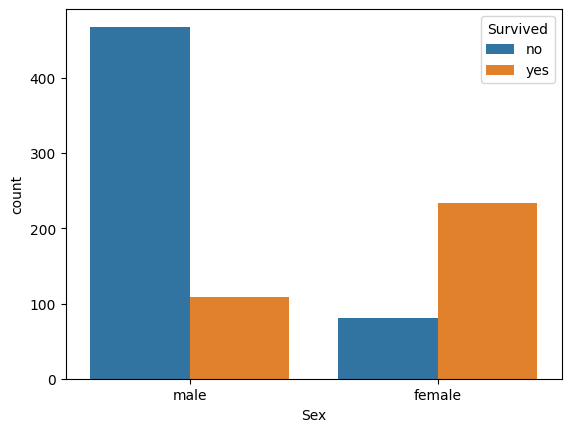

In [ ]:
# sns.countplot(data=df,x='Sex') same doitai
sns.countplot(x=df['Sex'],hue=df['Survived'])

In [4]:
# basic portion again recall

s=df.groupby('Sex').size()
s

,0
Sex,
female,314
male,577


In [5]:
s.index

Index(['female', 'male'], dtype='object', name='Sex')

In [6]:
# akane jeta hoise female male k alada table e divide korse
# r oder survival rate onosare k bece ace ba nai seta count kore dekaise

gender_split=df.groupby('Sex')['Survived'].value_counts()

gender_split

Sex     Survived
female  yes         233
        no           81
male    no          468
        yes         109
Name: count, dtype: int64

In [7]:
gender_split=df.groupby('Sex')['Survived'].value_counts(normalize=True)

gender_split

# akane jeta hoise female male k alada table e divide korse
# r oder survival rate onosare k bece ace ba nai  setar percentage ta count kore dekaise

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64

<Axes: xlabel='Pclass', ylabel='count'>

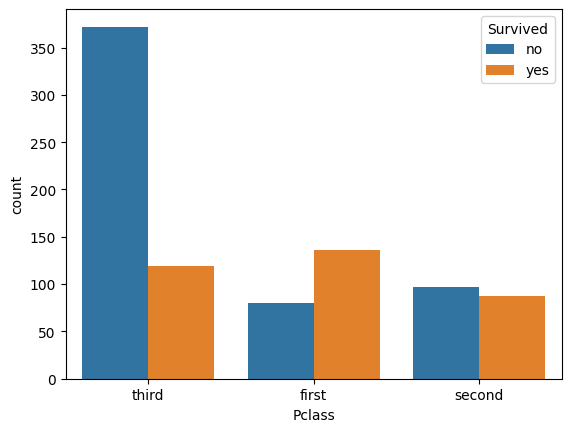

In [8]:
sns.countplot(x=df['Pclass'],hue=df['Survived'])

In [ ]:
pclass_split = df.groupby('Pclass')['Survived'].value_counts()

pclass_split

In [ ]:
pclass_split = df.groupby('Pclass')['Survived'].value_counts(normalize=True)

pclass_split
# female survived / total female
# male survived / total male

numerical and catagorical in barplot

Cat-Num Barplot একটি categorical variable (যেমন: City) এবং একটি numerical variable (যেমন: Sales) এর মধ্যে relationship দেখায়। প্রতিটি category-র জন্য numerical variable-এর mean বা aggregate value bar হিসেবে দেখানো হয়। Learning: Barplot categorical column-এর বিপরীতে numerical column-এর summary (সাধারণত mean) visualize করে।

<Axes: xlabel='Pclass', ylabel='Fare'>

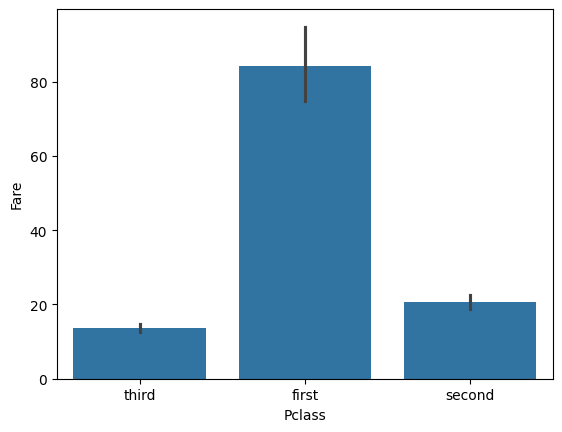

In [9]:
# Barplot ta mainly use kora hoi num + catagori  mane doita same ba
# differenet type use kora jai

sns.barplot(x=df['Pclass'],y=df['Fare'])

# first class er taka onek beshi

<Axes: xlabel='Survived', ylabel='Age'>

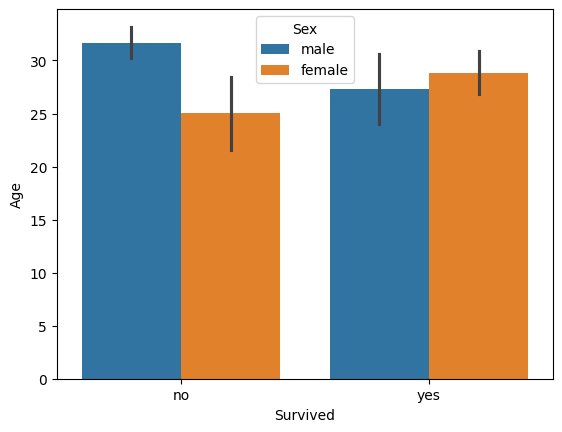

In [10]:
# male and female sapekke arekto pure lagtese age er basis e male and
# female koijon bece ace

sns.barplot(x=df['Survived'],y=df['Age'],hue=df['Sex'])

<Axes: xlabel='Survived', ylabel='Age'>

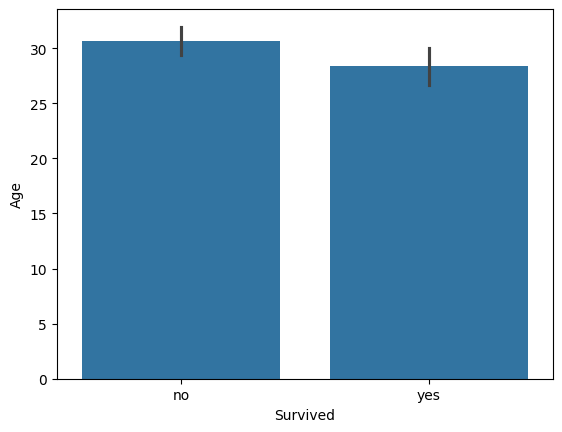

In [11]:
sns.barplot(x=df['Survived'],y=df['Age'])

<Axes: xlabel='Survived', ylabel='Age'>

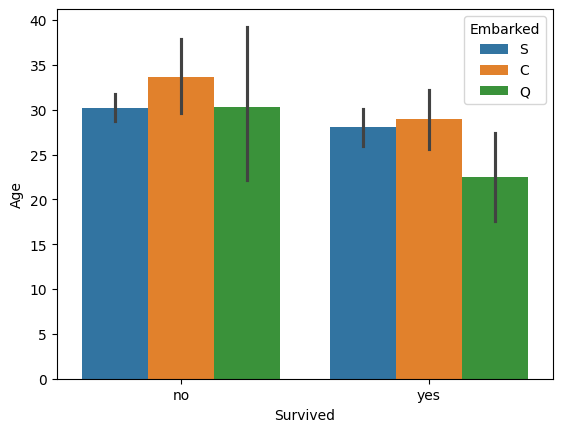

In [12]:
sns.barplot(x=df['Survived'],y=df['Age'],hue=df['Embarked'])

Multivariate Analysis -4 ( KDE plot for categorical discrepancy )

KDE plot একটি continuous variable-এর smooth curve দেখায় যা বোঝায় data কোথায় বেশি concentrated। Histogram-এর মতোই, তবে bars-এর বদলে একটি smooth line দেখা যায়। Learning: KDE plot দিয়ে সহজে বোঝা যায় data কোন range-এ বেশি আছে।

<Axes: xlabel='Age', ylabel='Density'>

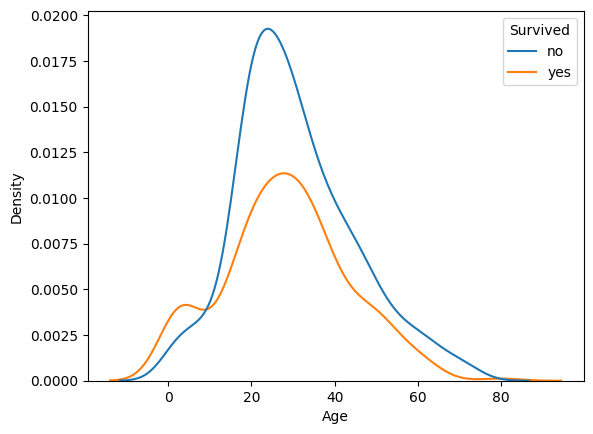

In [13]:
sns.kdeplot(x=df['Age'],hue=df['Survived'])
# sns.kdeplot(data =df , x ='Age', hue='Survived')

In [14]:
# tips datasheet  nia kaj start
df=sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

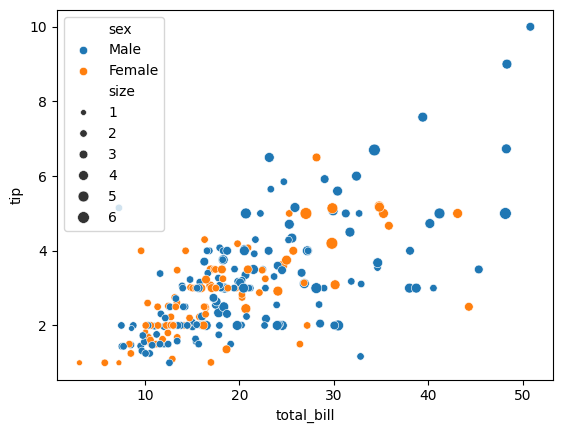

In [15]:
sns.scatterplot(data = df ,
                x='total_bill',
                y='tip',
                hue='sex',
                size='size')

# Learning: Scatterplot দিয়ে দুটি numerical column-এর মধ্যে সম্পর্ক আছে কিনা সহজে বোঝা যায়।


In [ ]:
pip list

In [ ]:
pip install ydata_profiling

In [ ]:
df

In [ ]:
from ydata_profiling import ProfileReport

profile=ProfileReport(df,title='Titanic Profile Report')

profile.to_file('my_report.html')